## **RESPON MODUL 3 DAN 4**

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

Kode diatas melakukan import terhadap tiga library utama untuk pengolahan citra (image processing). NumPy (np) digunakan untuk mengolah data gambar dalam bentuk array multidimensi atau matriks secara cepat dan efisien. Matplotlib (plt) berfungsi sebagai alat visualisasi untuk menampilkan grafik serta menampilkan gambar hasil pemrosesan. Sementara OpenCV (cv) adalah pustaka inti yang menyediakan berbagai fungsi dan algoritma untuk manipulasi serta analisis visual pada gambar atau video.

Pada bagian bawah, dilakukan perbandingan proses reading dan displaying gambar 'doomsday.png' menggunakan dua library berbeda, yaitu OpenCV dan Matplotlib. Berdasarkan kode yang dijalankan, OpenCV secara default membaca gambar dalam format BGR, sehingga diperlukan konversi terlebih dahulu ke format RGB menggunakan fungsi cv.cvtColor agar warna citra tidak tertukar saat di-plot, sementara Matplotlib melalui plt.imread dapat langsung membaca format RGB secara otomatis. Jika dianalisis dari hasil visual pada gambar dibawah, terdapat perbedaan kualitas yang cukup mencolok pada area latar belakang, dimana gambar hasil OpenCV di sebelah kiri terlihat dipenuhi oleh noise atau bintik-bintik abu-abu, sedangkan hasil Matplotlib di sebelah kanan tampak jauh lebih bersih dan halus. Perbedaan tersebut terjadi akibat karakteristik decoding dari masing-masing library, di mana Matplotlib secara default mampu menangani elemen alpha channel atau transparansi pada file PNG dengan baik, sementara OpenCV menerjemahkannya sebagai matriks uint8 standar tanpa konfigurasi tambahan sehingga area transparan tersebut justru terbaca sebagai noise.

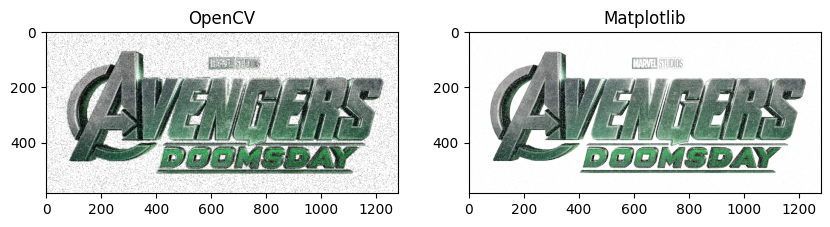

In [37]:
img_cv2 = cv.imread('doomsday.png')
img_doomsday = cv.cvtColor(img_cv2, cv.COLOR_BGR2RGB)

img_doomsday2 = plt.imread('doomsday.png')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_doomsday)
plt.title('OpenCV')

plt.subplot(1, 2, 2)
plt.imshow(img_doomsday2)
plt.title('Matplotlib')
plt.show()

In [38]:
def filter_rgb_manual(img, size, mode):
    height, width, channels = img.shape
    pad = size // 2
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    for c in range(channels):
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size, c]
                
                if mode == 'mean':
                    total = 0
                    for row in region:
                        for pixel in row:
                            total += pixel
                    canvas[i, j, c] = total // (size * size)
                    
                elif mode == 'median':
                    flat_list = []
                    for row in region:
                        for pixel in row:
                            flat_list.append(pixel)

                    flat_list.sort()
                    mid = len(flat_list) // 2
                    canvas[i, j, c] = flat_list[mid]
                
                elif mode == 'modus':
                    flat_values = []
                    for row in region:
                        for pixel in row:
                            flat_values.append(pixel)
                            
                    counts = {}
                    for val in flat_values:
                        counts[val] = counts.get(val, 0) + 1
                    
                    max_freq = 0
                    mode_val = 0
                    for val, freq in counts.items():
                        if freq > max_freq:
                            max_freq = freq
                            mode_val = val
                    canvas[i, j, c] = mode_val
    return canvas

Fungsi filter_rgb_manual diatas digunakan untuk mengimplementasikan operasi penyaringan spasial (spatial filtering) secara manual pada citra RGB dengan tiga pilihan metode, yaitu mean, median, dan modus. Proses diawali dengan menerapkan padding menggunakan np.pad berjenis edge untuk mengantisipasi reduksi dimensi pada piksel di bagian tepi citra berdasarkan ukuran kernel (size). Selanjutnya, algoritma menggunakan perulangan bertingkat (nested loop) untuk menelusuri setiap saluran warna (channel) serta seluruh koordinat baris dan kolom citra guna mengekstrak area lokal (region). Berdasarkan parameter mode yang dimasukkan, dilakukan perhitungan nilai piksel baru secara manual: menghitung rata-rata intensitas untuk filter mean, mengurutkan daftar piksel untuk mengambil nilai tengah untuk filter median, atau memanfaatkan struktur data dictionary untuk mencari nilai dengan frekuensi kemunculan tertinggi untuk filter modus. Setiap nilai hasil pemrosesan tersebut langsung disimpan ke dalam matriks canvas bertipe uint8 sebelum akhirnya dikembalikan sebagai citra utuh yang telah difilter.

Pada kode dibawah, dilakukan penyetaraan tipe data serta pengujian reduksi noise menggunakan filter median manual berukuran 3x3 (size=3) pada kedua citra. Sebelum pemrosesan filter, dilakukan pengondisian pada citra Matplotlib (img_doomsday2) untuk mengonversi nilainya dari format float (rentang 0.0 hingga 1.0) menjadi integer uint8 (rentang 0 hingga 255) agar memiliki tipe data yang seragam dengan citra OpenCV. Berdasarkan hasil analisis visual pada gambar dibawah, penerapan filter median ini terbukti sangat efektif dalam mengeliminasi bintik-bintik noise abu-abu yang sebelumnya mengotori latar belakang pada hasil OpenCV. Melalui mekanisme pengambilan nilai tengah dari area lokal piksel, kedua citra kini berhasil disajikan dengan kualitas visual yang sama-sama bersih, halus, dan konsisten tanpa merusak struktur garis atau tepi pada logo.

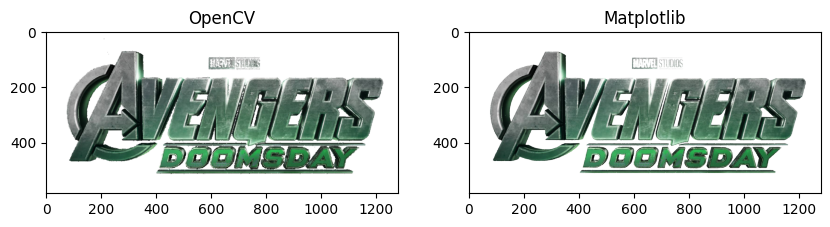

In [39]:
if img_doomsday2.dtype == np.float32 or img_doomsday2.max() <= 1.0:
    img_doomsday2 = (img_doomsday2 * 255).astype(np.uint8)

img_doomsday_rgb = cv.cvtColor(img_doomsday, cv.COLOR_BGR2RGB)

img_median_cv = filter_rgb_manual(img_doomsday, size=3, mode='median')
img_median_plt = filter_rgb_manual(img_doomsday2, size=3, mode='median')
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_median_cv)
plt.title('OpenCV')

plt.subplot(1, 2, 2)
plt.imshow(img_median_plt)
plt.title('Matplotlib')
plt.show()

In [40]:
def fungsi_dua(image, new_width, new_height):    
    old_height, old_width = image.shape[:2]     
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)     
    for i in range(new_height):         
        for j in range(new_width):             
            x = int(j * old_width / new_width)             
            y = int(i * old_height / new_height)            
            resized_image[i, j] = image[y, x]     
    return resized_image 

def convolution(img, kernel):
    size     = kernel.shape[0]
    pad_size = size // 2
    padded   = np.pad(img, pad_size, mode='constant')
    canvas   = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region       = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) 
    gy = convolution(img, kernely) 
    canvas = np.abs(gx) + np.abs(gy) 
    canvas = canvas * 255.0 / np.max(canvas) 
    return np.clip(canvas, 0, 255).astype(np.uint8) 

def threshold_manual(img, nilai_threshold):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i,j] > nilai_threshold:
                hasil[i,j] = 255
            else:
                hasil[i,j] = 0
    return hasil

def metode_satu(image,kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height//2
    hasil = np.zeros((height, width))
    for i in range(center, height-center):
        for j in range(center, width-center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            hasil[i+k-center,j+l-center] =255
                        else:
                            if hasil[i,j] !=255:
                                hasil[i,j] = 0
    return hasil

def gaussian_kernel(size=5, sigma=1.0):
    k = size // 2
    kernel = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            x, y = i - k, j - k
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def hapus_noise(img):
    h, w = img.shape
    hasil = np.zeros_like(img)
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            if img[i, j] == 255:
                tetangga = [img[i-1, j], img[i+1, j],
                            img[i, j-1], img[i, j+1],
                            img[i-1, j-1], img[i-1, j+1],
                            img[i+1, j-1], img[i+1, j+1]]
                if any(t == 255 for t in tetangga):
                    hasil[i, j] = 255
    return hasil

def metode_empat(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil

def hapus_noise_dalam(img, min_tetangga=3):
    h, w = img.shape
    hasil = img.copy()
    for i in range(1, h-1):
        for j in range(1, w-1):
            if img[i, j] == 255:
                tetangga_putih = (
                    int(img[i-1,j]==255) + int(img[i+1,j]==255) +
                    int(img[i,j-1]==255) + int(img[i,j+1]==255) +
                    int(img[i-1,j-1]==255) + int(img[i-1,j+1]==255) +
                    int(img[i+1,j-1]==255) + int(img[i+1,j+1]==255))
                if tetangga_putih < min_tetangga:
                    hasil[i, j] = 0
    return hasil

Kode di atas merupakan kumpulan fungsi implementasi manual untuk berbagai operasi dasar hingga tingkat lanjut dalam pengolahan citra digital, yang mencakup manipulasi geometri, filtering, segmentasi, dan morfologi. Operasi geometri berupa penskalaan dimensi citra diimplementasikan pada fungsi_dua dengan teknik interpolasi nearest neighbor, sedangkan pendeteksian tepi dilakukan secara manual melalui fungsi convolution dan edge yang menggabungkan nilai mutlak gradien arah horizontal serta vertikal. Untuk tahap segmentasi, fungsi threshold_manual digunakan untuk mengubah citra menjadi biner, sementara pembuatan matriks pembobotan spasial diakomodasi oleh gaussian_kernel. Selanjutnya, pemrosesan morfologi berupa dilasi diterapkan secara berulang melalui fungsi metode_satu dan metode_empat untuk mempertebal struktur objek, yang kemudian disempurnakan oleh fungsi hapus_noise serta hapus_noise_dalam guna membersihkan sisa noise terisolasi di sekitar objek menggunakan analisis ketetanggaan piksel.

In [41]:
sobelX = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]], dtype=np.float32)
sobelY = np.array([
    [-1,-2,-1],
    [0,0,0],
    [1,2,1]], dtype=np.float32)

kernel_dilated   = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]], dtype=np.float32)

Kode diatas mendeklarasikan beberapa matriks kernel berukuran 3x3 yang digunakan untuk proses deteksi tepi (edge detection) dan operasi morfologi pada citra. Matriks sobelX dan sobelY merupakan filter berbasis Operator Sobel, di mana sobelX berfungsi untuk menghitung nilai gradien citra pada arah horizontal, sedangkan sobelY digunakan untuk mendeteksi gradien pada arah vertikal. Sementara itu, kernel_dilated yang seluruh elemennya bernilai 1 bertindak sebagai elemen penumpu (structuring element) standar yang digunakan dalam operasi morfologi dilasi untuk mempertebal atau memperluas batas objek biner setelah tahap segmentasi.

Pada bagian bawah, dilakukan serangkaian tahapan digital image processing untuk mengekstraksi kontur tepi luar dari logo 'Avengers Doomsday' secara bersih dan presisi. Alur pemrosesan diawali dengan mengambil alpha channel sebagai acuan transparansi objek, dilanjutkan dengan reduksi noise awal lewat Gaussian filter dan binarisasi menggunakan thresholding manual pada nilai ambang 128. Setelah dilakukan penyesuaian skala dimensi citra menjadi 1240x540 piksel, operator Sobel horizontal dan vertikal diterapkan untuk menghitung gradien tepi, yang kemudian dipertegas kembali menggunakan thresholding kedua pada nilai 30 untuk mengisolasi garis kontur dari komponen lainnya. Tahap akhir melibatkan operasi morfologi dilasi untuk mempertebal struktur garis kontur, diikuti dengan eksekusi fungsi eliminasi noise ketetanggaan piksel sebanyak masing-masing dua kali perulangan. Berdasarkan analisis visual pada hasil gambar dibawah, kombinasi seluruh tahapan ini terbukti sangat efektif karena berhasil menghasilkan siluet kontur luar objek berwarna putih yang solid, tegas, dan kontinu di atas latar belakang hitam sempurna, tanpa menyisakan bintik-bintik pengganggu (noise) baik di sekitar logo utama maupun teks detail di atasnya.

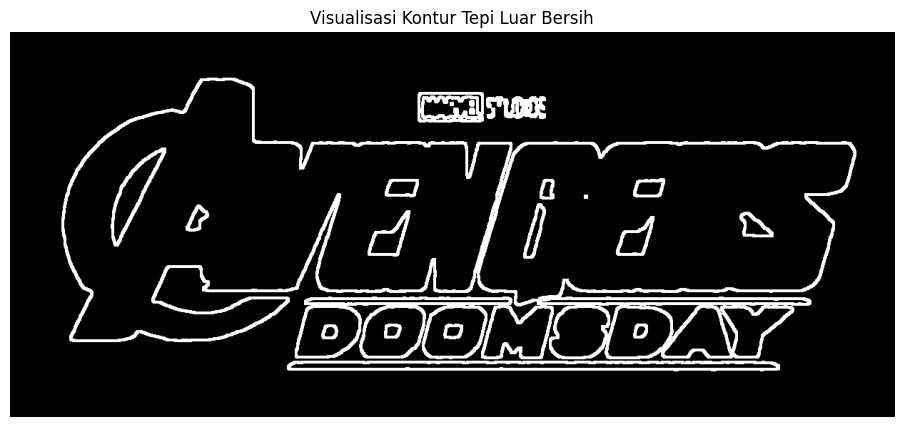

In [42]:
img_doomsday_cv2 = cv.imread('doomsday.png', cv.IMREAD_UNCHANGED)
komponen_a = img_doomsday_cv2[:, :, 3].astype(np.float32)
kernel_g = gaussian_kernel(size=7, sigma=3.0)
a_filtered = np.clip(convolution(komponen_a, kernel_g), 0, 255).astype(np.uint8)
masker_biner = threshold_manual(a_filtered, nilai_threshold=128)
masker_skala = fungsi_dua(masker_biner, new_width=1240, new_height=540)
gradien_m = edge(masker_skala, sobelX, sobelY)
tepi_tegas = threshold_manual(gradien_m, nilai_threshold=30)
kontur_dilasi = metode_satu(tepi_tegas, kernel_dilated)
output_matriks = kontur_dilasi.copy()

for _ in range(2):
    output_matriks = hapus_noise(output_matriks)
for _ in range(2):
    output_matriks = hapus_noise_dalam(output_matriks, min_tetangga=2)

plt.figure(figsize=(12, 5))
plt.imshow(output_matriks, cmap='gray')
plt.title("Visualisasi Kontur Tepi Luar Bersih")
plt.axis('off') 
plt.show()

In [43]:
def fungsi_dua_rgb(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized = np.zeros((new_height, new_width, 3), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized[i, j] = image[y, x]
    return resized

Fungsi fungsi_dua_rgb merupakan modifikasi dari fungsi penskalaan geometri sebelumnya yang kini dikonfigurasi khusus untuk menangani citra multi-saluran atau berwarna (RGB 3 channel). Algoritma ini mengimplementasikan teknik interpolasi nearest neighbor secara manual, di mana setiap koordinat piksel pada matriks baru (new_width dan new_height) dipetakan kembali ke koordinat citra asal menggunakan perhitungan rasio dimensi lama terhadap dimensi baru. Melalui perulangan bertingkat (nested loop) yang menjelajahi baris dan kolom, fungsi ini langsung menyalin vektor intensitas dari ketiga saluran warna sekaligus (image[y, x]) ke dalam matriks target resized bertipe uint8. Hasil analisis menunjukkan bahwa penyesuaian dimensi pada citra RGB berhasil dilakukan secara instan tanpa perlu memisahkan tiap saluran warna terlebih dahulu, meskipun karakteristik aliasing pada tepi objek tetap akan terlihat akibat penggunaan pembulatan berbasis integering langsung (int) untuk mencari indeks piksel terdekat.

Pada bagian bawah, dilakukan proses alpha blending dan contour overlaying untuk menghasilkan visualisasi akhir berupa penegasan tepi luar objek berwarna merah murni. Alur pemrosesan memanfaatkan saluran alfa yang dinormalisasi untuk memadukan (blend) citra asli dengan latar belakang putih murni, secara efektif menyelesaikan masalah noise bintik abu-abu yang sebelumnya muncul. Setelah citra hasil perpaduan dikonversi ke format RGB dan disesuaikan dimensinya menjadi 1240x540 piksel, masker kontur luar yang bersih diekstrak kembali menggunakan kombinasi filter Gaussian, operator Sobel, dilasi, serta pembersihan noise ketetanggaan. Kemudian, melalui perulangan bersyarat pada matriks target, setiap koordinat piksel yang terdeteksi sebagai bagian dari masker tepi (masker_c == 255) diubah intensitas warnanya menjadi merah murni [255, 0, 0], sehingga berhasil menyajikan garis pembatas luar objek yang sangat presisi, tajam, dan kontras untuk kebutuhan analisis bentuk geometris objek. Terakhir visual ditampilkan dengan hasil tanpa noise/bintik-bintik yang mengganggu dengan menggunakan operasi median untuk menghilangkannya.

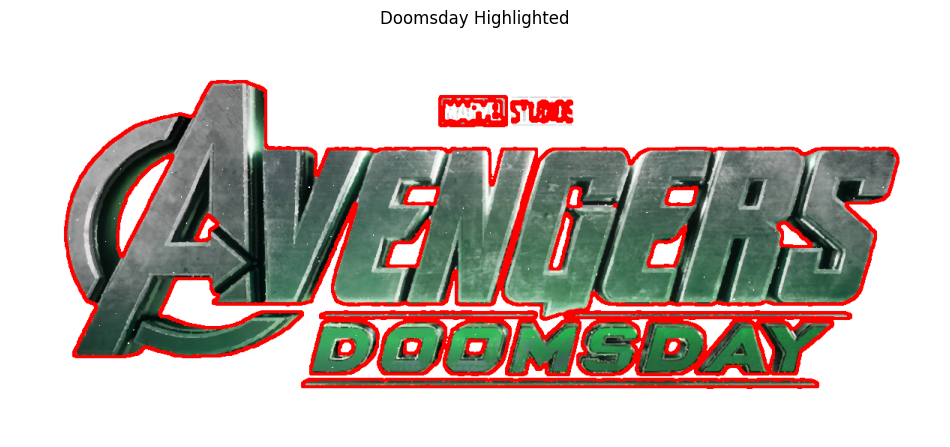

In [44]:
img_doomsday_cv2 = cv.imread('doomsday.png', cv.IMREAD_UNCHANGED)
matriks_bgr = img_doomsday_cv2[:, :, :3]
matriks_alpha = img_doomsday_cv2[:, :, 3]
alpha_normal = matriks_alpha.astype(np.float32) / 255.0
h_ori, w_ori = matriks_alpha.shape
img_blended = np.zeros((h_ori, w_ori, 3), dtype=np.uint8)

for c in range(3):
    channel_bgr = matriks_bgr[:, :, c].astype(np.float32)
    hasil_blend_channel = (channel_bgr * alpha_normal) + (255.0 * (1.0 - alpha_normal))
    img_blended[:, :, c] = hasil_blend_channel.astype(np.uint8)

img_rgb = np.zeros_like(img_blended)
img_rgb[:, :, 0] = img_blended[:, :, 2]
img_rgb[:, :, 1] = img_blended[:, :, 1]
img_rgb[:, :, 2] = img_blended[:, :, 0]

img_r = fungsi_dua_rgb(img_rgb, 1240, 540)

kernel_blur = gaussian_kernel(size=7, sigma=3.0)
alpha_blur = convolution(matriks_alpha.astype(np.float32), kernel_blur)

masker_alpha = threshold_manual(alpha_blur, nilai_threshold=128)
mask_resized = fungsi_dua(masker_alpha, 1240, 540)

img_edge = edge(mask_resized, sobelX, sobelY)
img_thresh = threshold_manual(img_edge, nilai_threshold=30)
img_dilated = metode_satu(img_thresh, kernel_dilated)

masker_c = img_dilated.copy()
for i in range(2):
    masker_c = hapus_noise(masker_c)

for i in range(2):
    masker_c = hapus_noise_dalam(masker_c, min_tetangga=2)

img_o_highlight = img_r.copy()
h_final, w_final = masker_c.shape

for i in range(h_final):
    for j in range(w_final):
        if masker_c[i, j] == 255:
            img_o_highlight[i, j, 0] = 255
            img_o_highlight[i, j, 1] = 0  
            img_o_highlight[i, j, 2] = 0  

img_fixed_noise = filter_rgb_manual(img_o_highlight, size=3, mode='median')

plt.figure(figsize=(12, 6))
plt.imshow(img_fixed_noise)
plt.title("Doomsday Highlighted")
plt.axis('off')
plt.show()